In [ ]:
!pip install -U onnx onnxscript onnxruntime

In [2]:
# Imports

import torch
import torchvision.models as models
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import v2
from google.colab import files, drive
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import time
from datetime import timedelta

In [3]:
# Connect to drive and preliminary setup

drive.mount("/content/drive")
NOTEBOOK_DIR = "/content/drive/MyDrive/Colab Projects/Dog or Dough"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


In [4]:
# Define transfer learning architecture

model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
model.classifier[3] = nn.Linear(in_features=1280, out_features=2)
model.to(device)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [13]:
# Data and preprocessing

# Define preprocessing as per https://docs.pytorch.org/vision/main/models/generated/torchvision.models.mobilenet_v3_large.html#torchvision.models.MobileNet_V3_Large_Weights
class OnTheFlyAugmentations(nn.Module):
    def __init__(self):
        super().__init__()
        self.aug = v2.Compose([
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomRotation(10),
            v2.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.05
            ),
            v2.RandomPerspective(distortion_scale=0.2, p=0.2)
        ])

    def forward(self, img):
        return self.aug(img)

RESCALE_SIZE = 232
IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
train_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize(RESCALE_SIZE, interpolation=v2.InterpolationMode.BILINEAR),
    v2.CenterCrop(IMAGE_SIZE),
    OnTheFlyAugmentations(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
val_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize(RESCALE_SIZE, interpolation=v2.InterpolationMode.BILINEAR),
    v2.CenterCrop(IMAGE_SIZE),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

batch_size = 32

train_dataset = ImageFolder(NOTEBOOK_DIR + "/data/train/", train_transforms)
val_dataset = ImageFolder(NOTEBOOK_DIR + "/data/val/", val_transforms)
test_dataset = ImageFolder(NOTEBOOK_DIR + "/data/test/", val_transforms)

train_loader = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

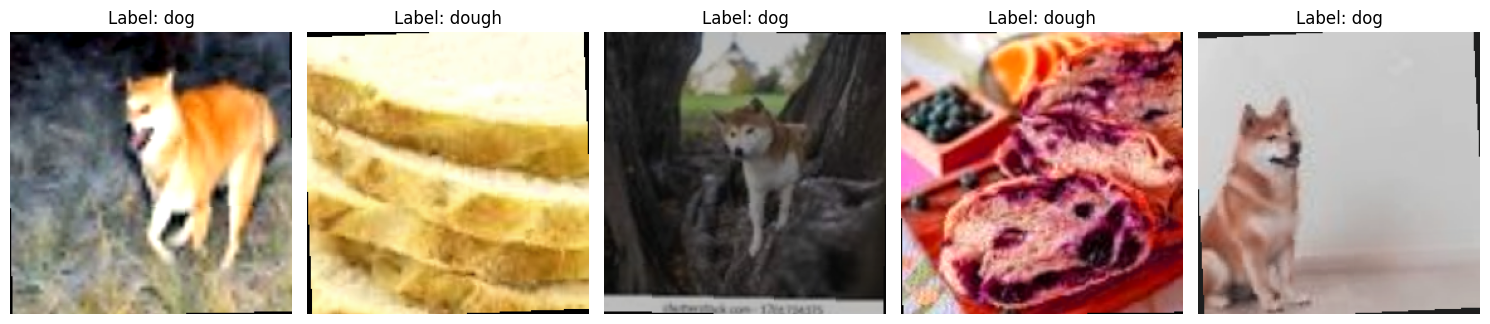

In [6]:
# Visualize training images

def unnormalize(x):
    return (x * torch.tensor(IMAGENET_STD).view(3, 1, 1) + torch.tensor(IMAGENET_MEAN).view(3, 1, 1)).clamp(0, 1)

# Pick 5 random indices
indices = torch.randperm(len(train_dataset))[:5]
images = [train_dataset[i][0] for i in indices]
labels = [train_dataset[i][1] for i in indices]

plt.figure(figsize=(15,5))
for i in range(5):
    img = unnormalize(images[i]).permute(1,2,0).cpu()
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(f"Label: {train_dataset.classes[labels[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [7]:
# Define optimizer, scheduler, loss function, and training config

num_warmup_epochs = 10
num_epochs = 100
patience = 20

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1, total_iters=num_warmup_epochs)
main_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs - num_warmup_epochs, eta_min=1e-7)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, main_scheduler],
    milestones=[num_warmup_epochs]
)

criterion = nn.CrossEntropyLoss()

In [21]:
# Train helpers

def train_step(model, dataloader, loss_fn, optimizer):
    model.train()
    running_loss = 0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc="Train"):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0) # total loss for curr batch
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    per_class_precision = precision_score(all_labels, all_preds, average=None)
    per_class_recall = recall_score(all_labels, all_preds, average=None)
    per_class_f1 = f1_score(all_labels, all_preds, average=None)

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    macro_precision = precision_score(all_labels, all_preds, average='macro')
    macro_recall = recall_score(all_labels, all_preds, average='macro')
    accuracy = accuracy_score(all_labels, all_preds)

    train_loss = running_loss / len(train_loader.dataset) # avg loss of a sample over curr epoch
    
    print(f"Train Loss: {train_loss:.4f} | Accuracy: {accuracy:.4f}")
    print(f"Macro Precision: {macro_precision:.4f}, Macro Recall: {macro_recall:.4f}, Macro F1: {macro_f1:.4f}")
    for i, (p, r, f) in enumerate(zip(per_class_precision, per_class_recall, per_class_f1)):
        print(f"Class {train_dataset.classes[i]} -> Precision: {p:.4f}, Recall: {r:.4f}, F1: {f:.4f}")

    return train_loss

def val_step(model, dataloader, criterion,):
    model.eval()
    running_loss = 0

    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    per_class_precision = precision_score(all_labels, all_preds, average=None)
    per_class_recall = recall_score(all_labels, all_preds, average=None)
    per_class_f1 = f1_score(all_labels, all_preds, average=None)

    macro_precision = precision_score(all_labels, all_preds, average='macro')
    macro_recall = recall_score(all_labels, all_preds, average='macro')
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    accuracy = accuracy_score(all_labels, all_preds)

    val_loss = running_loss / len(val_loader.dataset)

    print(f"Validation Loss: {val_loss:.4f} | Accuracy: {accuracy:.4f}")
    print(f"Macro Precision: {macro_precision:.4f}, Macro Recall: {macro_recall:.4f}, Macro F1: {macro_f1:.4f}")
    for i, (p, r, f) in enumerate(zip(per_class_precision, per_class_recall, per_class_f1)):
        print(f"Class {val_loader.dataset.classes[i]} -> Precision: {p:.4f}, Recall: {r:.4f}, F1: {f:.4f}")

    return val_loss, macro_f1

def plot_loss(train_losses, val_losses, save_path):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training / Validation Loss")
    plt.legend()
    plt.grid(True)

    # IMPORTANT: save BEFORE show/close
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

def export_model(model):
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    onnx_path = NOTEBOOK_DIR + "/model.onnx"

    model.eval()

    torch.onnx.export(
        model, 
        dummy_input, 
        onnx_path, 
        export_params=True,
        opset_version=18,
        do_constant_folding=True,
        input_names = ['input'],
        output_names = ['output'],
        dynamic_axes={'input' : {0 : 'batch_size'},
                    'output' : {0 : 'batch_size'}}
    )

    print(f"Model exported to ONNX at {onnx_path}")

In [ ]:
# Training

best_f1 = 0
epochs_without_improvement = 0
train_losses = []
val_losses = []
epoch_times = []
for epoch in range(1, num_epochs + 1):
    epoch_start = time.time()
    print(f"Epoch: {epoch}/{num_epochs}")
    print("-" * 30)

    train_loss = train_step(model, train_loader, criterion, optimizer)
    val_loss, val_f1 = val_step(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    plot_loss(train_losses, val_losses)

    epoch_times.append(time.time() - epoch_start)
    avg_time = sum(epoch_times) / len(epoch_times)
    eta = avg_time * (num_epochs - epoch)
    print(f"ETA: {str(timedelta(seconds=int(eta)))}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), NOTEBOOK_DIR + "/best_ckpt.pth")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print("Early stopping triggered")
            break
    print(f"Patience: {epochs_without_improvement}/{patience}")


export_model(model)

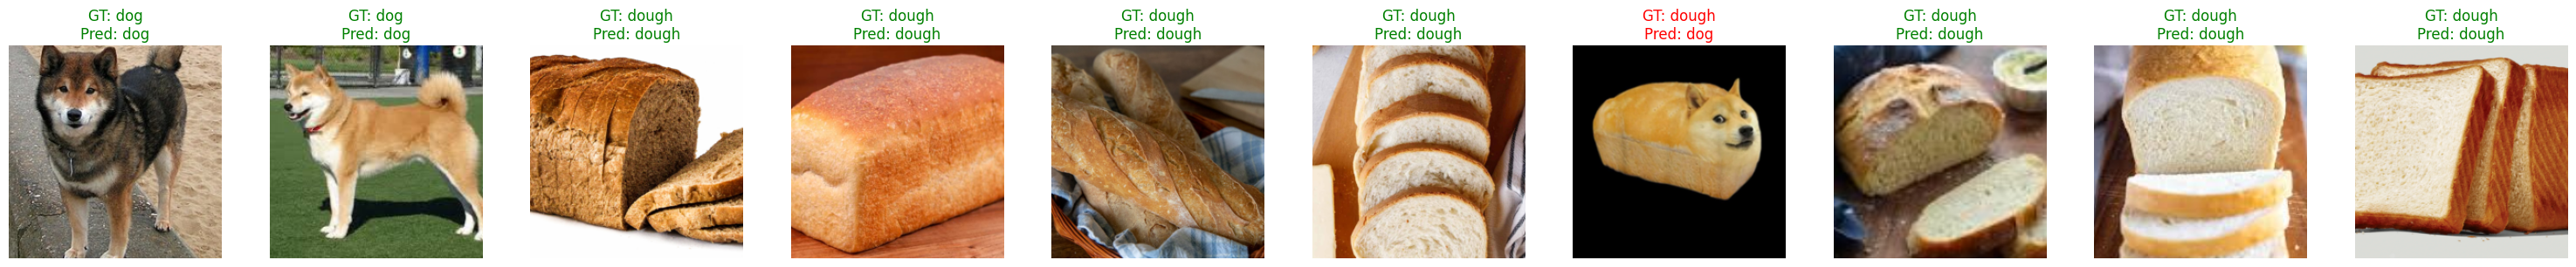

In [ ]:
state_dict = torch.load(NOTEBOOK_DIR + "/best_ckpt.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()
def visualize_predictions(model, dataloader, class_names, num_images=8, device='cuda'):
    """
    Visualize images and predictions from a model and a DataLoader.
    """
    model.eval()
    
    images, labels = next(iter(dataloader))
    images = images.to(device)
    labels = labels.to(device)
    
    with torch.inference_mode():
        outputs = model(images)
        preds = outputs.argmax(dim=1)
    
    images = images.cpu()
    labels = labels.cpu()
    preds = preds.cpu()
    
    mean = torch.tensor(IMAGENET_MEAN, dtype=images.dtype).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD, dtype=images.dtype).view(3,1,1)
    
    k = min(num_images, images.size(0))
    plt.figure(figsize=(3*k, 3))
    
    for i in range(k):
        img = (images[i] * std + mean).clamp(0,1).permute(1,2,0)
        gt = class_names[labels[i]]
        pred = class_names[preds[i]]
        color = 'green' if gt == pred else 'red'
        
        plt.subplot(1, k, i+1)
        plt.imshow(img)
        plt.title(f"GT: {gt}\nPred: {pred}", color=color)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_loader, test_dataset.classes, 10)